# Crypto Statistical Arbitrage — The Signal Search

The combined book in `01_combined_book.ipynb` keeps three signals: **proximity-to-high momentum**,
**idiosyncratic low-volatility**, and **funding carry**. They are what survived a search across roughly
140 configurations of signal, universe, construction and horizon. This notebook is that search — every
rejected idea, coded and run, not summarised in a one-line table.

Two reasons it earns its own notebook. First, the failures are as instructive as the survivors: they map
out *why* an edge is or isn't real. Second, running them here — with the same engine, same costs, same
screens — is what backs the claim that the search was honest rather than a story told after the fact.

**How each candidate is judged.** Identical to the survivors: design on Train (2020-2023), read Validation
(2024-2026) as out-of-sample, keep only what is positive in *both* windows, charge 20 bps on turnover, and
require near-zero market beta. Every failure below is one of four recurring traps:

| Trap | What it looks like | How the survivors avoid it |
|---|---|---|
| **A · Beta dressed as alpha** | great returns, but β≈1 to BTC | survivors have β≈0 |
| **B · The cost wall** | positive gross, negative after turnover | survivors are low-turnover weekly books |
| **C · Data-snooping** | best-of-N noisy backtests, or a scale artifact | survivors clear a deflated Sharpe |
| **D · Regime luck** | positive only in the recent window | survivors are positive in *both* windows |

All plumbing (data, engine, metrics, signal formulas) is imported from the `qsa/` package, so the cells
below read as research.


In [1]:
import warnings
# Scope the filter (P2.5): silence known-benign pandas/statsmodels/matplotlib chatter but let a genuine
# RuntimeWarning (e.g. an accidental divide-by-zero in a ratio signal) still surface.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root/"qsa").exists() and (_root.parent/"qsa").exists(): _root = _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mtick

from qsa import Dataset, apply_style, style_table, CLR
from qsa.config import TRAIN, VAL, FULL, TCOST, ANN, seg
from qsa.engine import eq_weights, cs_weights, backtest, sharpe, sortino, maxdd, alpha_beta, hac_tstat
from qsa.engine import dn_weights as _dn
from qsa import signals as sig

apply_style()
ds = Dataset.load()
btc, ew, ret_all, close_all, resid_all, liq60 = ds.btc, ds.ew, ds.ret_all, ds.close_all, ds.resid_all, ds.liq60
def dn(signal, topN=None, screen=True): return _dn(signal, ds, topN=topN, screen=screen)

# One record per candidate, so the final scoreboard writes itself.
REC = {}
def record(name, net, trap, turn=None):
    REC[name] = {"Train": sharpe(seg(net, TRAIN)), "Val (OOS)": sharpe(seg(net, VAL)),
                 "Val Sortino": sortino(seg(net, VAL)), "MaxDD": maxdd(seg(net, FULL)),
                 "β vs BTC": alpha_beta(net, btc, FULL)["beta"],
                 "Turn/day": (float(turn.mean()) if turn is not None else np.nan), "Trap": trap}
    return REC[name]

def scoreboard(names, caption, vmax=2):
    df = pd.DataFrame({n: REC[n] for n in names}).T[["Train","Val (OOS)","Val Sortino","MaxDD","β vs BTC","Turn/day","Trap"]]
    sty = (df.style.format({"Train":"{:+.2f}","Val (OOS)":"{:+.2f}","Val Sortino":"{:+.2f}",
            "β vs BTC":"{:+.2f}","MaxDD":"{:.0%}","Turn/day":"{:.2f}"}, na_rep="–")
           .background_gradient(cmap="RdYlGn", subset=["Train","Val (OOS)"], vmin=-vmax, vmax=vmax, axis=None))
    display(style_table(sty, caption))

# The bar to clear: the three survivors, scored the same way (imported from qsa.signals).
mom_net, mom_turn = backtest(dn(sig.near_high(ds, 90)), ret_all, rebal=7)
bab_net, bab_turn = backtest(dn(sig.idio_vol(ds, 60), topN=50), ret_all, rebal=7)
record("SURVIVOR: Momentum (near-high)", mom_net, "—", mom_turn)
record("SURVIVOR: Low-volatility", bab_net, "—", bab_turn)
scoreboard(["SURVIVOR: Momentum (near-high)","SURVIVOR: Low-volatility"],
           "Reference — the two price/volume survivors, scored on the same ruler as every candidate below "
           "(carry is a long-spot/short-perp book, examined in notebook 01). This is the bar to clear: "
           "positive in BOTH windows, near-zero beta, low turnover.")
print("Setup ready. Every candidate below is built with dn()/backtest — the same liquidity + short screen "
      "and 20 bps turnover cost as the survivors.")


Data cache present: loading from crypto_data/processed/ (no download needed).


,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
SURVIVOR: Momentum (near-high),+0.68,+0.65,+0.87,-49%,-0.07,0.07,—
SURVIVOR: Low-volatility,+0.36,+1.92,+2.75,-60%,-0.07,0.04,—


Setup ready. Every candidate below is built with dn()/backtest — the same liquidity + short screen and 20 bps turnover cost as the survivors.


## 1 · Momentum & trend that don't work

Momentum is the headline idea, so it gets the most attention. Three natural versions all fail out-of-sample
— each for a different, instructive reason. The survivor (proximity-to-high) works precisely because it
sidesteps the flaw that sinks these.


,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
Directional trend (long-flat),+1.13,-0.40,-0.54,-90%,+0.97,0.24,A · beta
Regime-switch trend (BTC-gated),+2.02,+0.12,+0.16,-60%,+0.52,0.13,A · beta
"X-sectional momentum (60d, raw)",-1.20,-0.61,-0.84,-92%,+0.00,0.08,reversal noise
Long-horizon momentum (270d),-1.54,+1.11,+1.72,-88%,+0.01,0.02,D · regime luck
SURVIVOR: Momentum (near-high),+0.68,+0.65,+0.87,-49%,-0.07,0.07,—


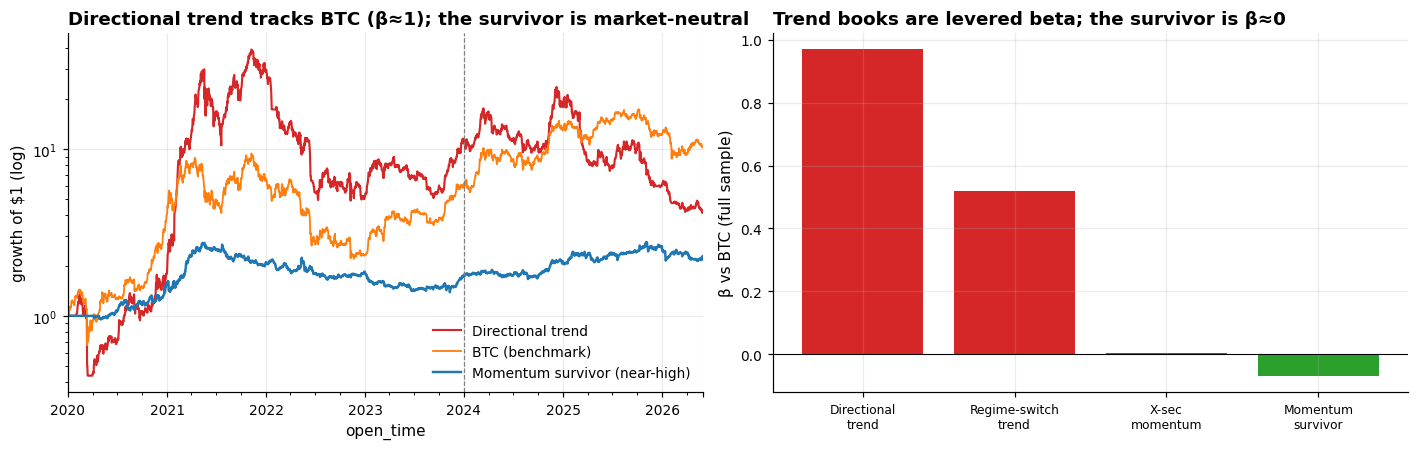

Directional trend: train +1.13 but out-of-sample -0.40 at β=+0.97 — it is BTC with extra steps, and OOS it trails buy-and-hold (+0.72). Gating on BTC's own trend just dials the beta down without adding alpha. Raw cross-sectional momentum is negative in both windows: at 30-90 day horizons 'recent winners' are half short-term-reversal noise — exactly the contamination that ranking on proximity-to-high avoids. Long-horizon momentum is the regime-luck trap: +1.11 OOS but -1.54 in-sample, so it only 'works' in the recent window.


In [2]:
# (a) Directional time-series trend: long the coins whose 30/60/90-day trend is up, long-flat, top-15.
conv = sum((ds.close.pct_change(h, fill_method=None) > 0).astype(float) for h in (30,60,90)) / 3.0
trend_net, trend_turn = backtest(eq_weights(conv), ds.ret)
record("Directional trend (long-flat)", trend_net, "A · beta", trend_turn)

# (b) Regime-switch trend: same trend, but only take it when BTC itself is in an up-trend (a common "fix").
gate = (btc.rolling(60).mean().shift(1) > 0).astype(float)
rs_net, rs_turn = backtest(eq_weights(conv).mul(gate, axis=0), ds.ret)
record("Regime-switch trend (BTC-gated)", rs_net, "A · beta", rs_turn)

# (c) Cross-sectional raw momentum: long recent winners / short losers over 60 days, market-neutral.
csm_net, csm_turn = backtest(dn(sig.cs_momentum(ds, 60)), ret_all, rebal=7)
record("X-sectional momentum (60d, raw)", csm_net, "reversal noise", csm_turn)

# (d) Long-horizon momentum: 9-month (270d) formation, held monthly — the "classic" academic momentum.
lh_net, lh_turn = backtest(dn(sig.long_horizon_momentum(ds, 270)), ret_all, rebal=30)
record("Long-horizon momentum (270d)", lh_net, "D · regime luck", lh_turn)

scoreboard(["Directional trend (long-flat)","Regime-switch trend (BTC-gated)",
            "X-sectional momentum (60d, raw)","Long-horizon momentum (270d)","SURVIVOR: Momentum (near-high)"],
           "Naive momentum vs the survivor. Directional and regime-gated trend are high-beta longs; "
           "raw cross-sectional momentum is short-term-reversal noise; long-horizon looks good only OOS.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nm, s, c, lw in [("Directional trend", trend_net, CLR["reject"], 1.4), ("BTC (benchmark)", btc, CLR["BTC"], 1.2),
                     ("Momentum survivor (near-high)", mom_net, CLR["Momentum"], 1.6)]:
    (1+seg(s, FULL).fillna(0)).cumprod().plot(ax=ax[0], label=nm, color=c, lw=lw)
ax[0].set_yscale("log"); ax[0].axvline(pd.Timestamp(VAL[0]), ls="--", c="grey", lw=.8)
ax[0].set_title("Directional trend tracks BTC (β≈1); the survivor is market-neutral"); ax[0].set_ylabel("growth of \$1 (log)"); ax[0].legend()
betas = pd.Series({"Directional\ntrend": alpha_beta(trend_net, btc, FULL)["beta"],
                   "Regime-switch\ntrend": alpha_beta(rs_net, btc, FULL)["beta"],
                   "X-sec\nmomentum": alpha_beta(csm_net, btc, FULL)["beta"],
                   "Momentum\nsurvivor": alpha_beta(mom_net, btc, FULL)["beta"]})
ax[1].bar(range(len(betas)), betas.values, color=[CLR["reject"],CLR["reject"],CLR["reject"],CLR["keep"]])
ax[1].axhline(0, c="k", lw=.7); ax[1].set_xticks(range(len(betas))); ax[1].set_xticklabels(betas.index, fontsize=8)
ax[1].set_ylabel("β vs BTC (full sample)"); ax[1].set_title("Trend books are levered beta; the survivor is β≈0")
plt.tight_layout(); plt.show()
print(f"Directional trend: train {REC['Directional trend (long-flat)']['Train']:+.2f} but out-of-sample "
      f"{REC['Directional trend (long-flat)']['Val (OOS)']:+.2f} at β={REC['Directional trend (long-flat)']['β vs BTC']:+.2f} "
      f"— it is BTC with extra steps, and OOS it trails buy-and-hold ({sharpe(seg(btc,VAL)):+.2f}). Gating on BTC's own "
      f"trend just dials the beta down without adding alpha. Raw cross-sectional momentum is negative in both windows: "
      f"at 30-90 day horizons 'recent winners' are half short-term-reversal noise — exactly the contamination that "
      f"ranking on proximity-to-high avoids. Long-horizon momentum is the regime-luck trap: {REC['Long-horizon momentum (270d)']['Val (OOS)']:+.2f} "
      f"OOS but {REC['Long-horizon momentum (270d)']['Train']:+.2f} in-sample, so it only 'works' in the recent window.")


## 2 · Reversal — a real signal that the cost wall eats

Short-horizon reversal (buy recent losers, sell recent winners) has a genuine, statistically significant
predictive signal in crypto. It is also the cleanest example of the cost wall: the edge lives at 1-3 day
horizons, so harvesting it means turning the book over roughly once a day, and 20 bps on that turnover
swamps the gross return. This is why the combined book has no reversal sleeve — not because the signal
isn't there, but because you can't keep it after costs.


,Gross Sharpe (train),Gross Sharpe (val),NET Sharpe (train),NET Sharpe (val),Turnover/day
Reversal 1d,+0.11,-0.94,-1.87,-3.89,1.39
Reversal 2d,+0.25,-0.96,-1.30,-3.06,0.99
Reversal 3d,-0.26,-0.92,-1.53,-2.63,0.81
Reversal 5d,-0.40,-1.10,-1.40,-2.53,0.63


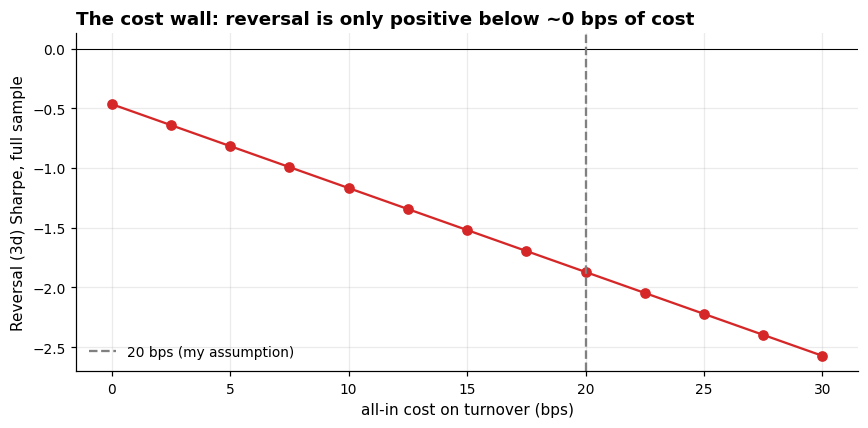

The 3-day book turns over 0.81x of the portfolio per day. Its full-sample Sharpe is -0.47 gross but -1.87 net at 20 bps — it only clears zero below roughly 0 bps, far under any realistic crypto cost. Idiosyncratic (beta-neutral) reversal turns over even faster (0.80/day) and fails the same way (-2.68 val), despite a highly significant rank-IC (t=+0). Significant is not the same as tradeable.


In [3]:
# Short-horizon price reversal at 1/2/3/5-day horizons, market-neutral, daily rebalance (the horizon it needs).
rev_nets = {}
for L in (1, 2, 3, 5):
    w = dn(sig.reversal(ds, L))
    g, _ = backtest(w, ret_all, tcost=0.0)          # gross
    n, t = backtest(w, ret_all, tcost=TCOST)        # net of 20 bps
    rev_nets[L] = (g, n, t)
    record(f"Reversal {L}d (net 20bps)", n, "B · cost wall", t)
# Idiosyncratic (beta-neutral) reversal — even higher turnover.
idio_w = dn(sig.idio_reversal(ds, 3))
idio_g, _ = backtest(idio_w, ret_all, tcost=0.0); idio_n, idio_t = backtest(idio_w, ret_all, tcost=TCOST)
record("Idiosyncratic reversal (3d)", idio_n, "B · cost wall", idio_t)

g3, n3, t3 = rev_nets[3]
gn = pd.DataFrame({f"Reversal {L}d": {"Gross Sharpe (train)": sharpe(seg(rev_nets[L][0], TRAIN)),
        "Gross Sharpe (val)": sharpe(seg(rev_nets[L][0], VAL)), "NET Sharpe (train)": sharpe(seg(rev_nets[L][1], TRAIN)),
        "NET Sharpe (val)": sharpe(seg(rev_nets[L][1], VAL)), "Turnover/day": rev_nets[L][2].mean()} for L in (1,2,3,5)}).T
display(style_table(gn.style.format({c: ("{:.2f}" if c=="Turnover/day" else "{:+.2f}") for c in gn.columns})
        .background_gradient(cmap="RdYlGn", subset=["NET Sharpe (train)","NET Sharpe (val)"], vmin=-2, vmax=2, axis=None),
        "Short-horizon reversal, gross vs net. Even the gross signal is thin on the liquid universe (the strong "
        "reversal lives in the illiquid tail the $5M screen removes); after 20 bps on ~1x/day turnover it is deeply negative."))

# The cost wall, drawn: net Sharpe of the 3-day book as the cost assumption rises from 0.
costs = np.linspace(0, 0.0030, 13)
walls = [sharpe(seg(backtest(dn(sig.reversal(ds, 3)), ret_all, tcost=c)[0], FULL)) for c in costs]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs*1e4, walls, marker="o", color=CLR["reject"])
ax.axhline(0, c="k", lw=.7); ax.axvline(20, ls="--", c="grey", label="20 bps (my assumption)")
be = np.interp(0, walls[::-1], (costs*1e4)[::-1])
ax.set_xlabel("all-in cost on turnover (bps)"); ax.set_ylabel("Reversal (3d) Sharpe, full sample")
ax.set_title("The cost wall: reversal is only positive below ~{:.0f} bps of cost".format(max(be,0))); ax.legend()
plt.tight_layout(); plt.show()
print(f"The 3-day book turns over {t3.mean():.2f}x of the portfolio per day. Its full-sample Sharpe is "
      f"{sharpe(seg(g3,FULL)):+.2f} gross but {sharpe(seg(n3,FULL)):+.2f} net at 20 bps — it only clears zero below "
      f"roughly {max(be,0):.0f} bps, far under any realistic crypto cost. Idiosyncratic (beta-neutral) reversal turns over "
      f"even faster ({idio_t.mean():.2f}/day) and fails the same way ({sharpe(seg(idio_n,VAL)):+.2f} val), despite a "
      f"highly significant rank-IC (t={hac_tstat((resid_all.rolling(3).sum()*-1).where(liq60).mean(1).fillna(0), FULL, 5):+.0f}). "
      f"Significant is not the same as tradeable.")


## 3 · Intraday and microstructure signals

If a daily signal dies on turnover, an intraday one dies faster. And a "signal" built from the wrong units
can look brilliant for a reason that has nothing to do with predictive power.


In [4]:
# (a) 4-hour cross-sectional momentum & reversal on the top-15 (6 bars/day => turnover is fatal).
r4 = ds.fetch_4h(ds.UNIV); ANN4 = np.sqrt(6*365)
def bt4(signal, tcost):
    w = cs_weights(signal); pnl = (w.shift(1)*r4).sum(1)
    turn = (w.shift(1)-w.shift(2)).abs().sum(1).fillna(0.0)
    return pnl - tcost*turn, turn
h4 = {}
for nm, s in [("4h momentum (6-bar)", r4.rolling(6).sum()), ("4h reversal (1-bar)", -r4)]:
    g, _ = bt4(s, 0.0); n, t = bt4(s, TCOST)
    # annualise on the 4h clock, then rescale to the daily-Sharpe convention for comparability
    h4[nm] = {"Gross Sharpe": (g.mean()/g.std())*ANN4, "NET Sharpe (20bps)": (n.mean()/n.std())*ANN4, "Turnover/bar": t.mean()}
display(style_table(pd.DataFrame(h4).T.style.format({"Gross Sharpe":"{:+.2f}","NET Sharpe (20bps)":"{:+.2f}","Turnover/bar":"{:.2f}"})
        .background_gradient(cmap="RdYlGn", subset=["NET Sharpe (20bps)"], vmin=-6, vmax=6, axis=None),
        "4-hour intraday books — a positive gross momentum signal is annihilated by trading six times a day."))

# (b) "Order flow": the RIGHT idea, done two ways. Raw taker-buy volume is in token units (a scale artifact
#     — 1 BTC != 1 SHIB), so cross-sectional comparison is meaningless. The scale-free version (buy-dollar
#     fraction of total dollar volume) is the honest test.
of_raw, of_raw_t = backtest(dn(sig.orderflow_raw(ds, 5)), ret_all, rebal=7)
of_sf,  of_sf_t  = backtest(dn(sig.orderflow_scalefree(ds, 5)), ret_all, rebal=7)
record("Order-flow (raw taker-buy base)", of_raw, "C · snooping", of_raw_t)
record("Order-flow (scale-free $ fraction)", of_sf, "C · snooping", of_sf_t)
scoreboard(["Order-flow (raw taker-buy base)","Order-flow (scale-free $ fraction)"],
           "Order flow — the raw-volume version looks like a strong edge, but it is a units artifact; the scale-free "
           "version that actually tests the hypothesis has no out-of-sample edge.", vmax=2)
print(f"4h momentum is {h4['4h momentum (6-bar)']['Gross Sharpe']:+.1f} gross but {h4['4h momentum (6-bar)']['NET Sharpe (20bps)']:+.1f} "
      f"net — six rebalances a day is a wall no signal this size clears. Order flow is the data-snooping trap in miniature: "
      f"raw taker-buy volume scores val {REC['Order-flow (raw taker-buy base)']['Val (OOS)']:+.2f}, but that is a scale artifact "
      f"(comparing token counts across coins of wildly different unit prices). Measured properly — buy-dollar fraction of total "
      f"dollar volume — the edge evaporates ({REC['Order-flow (scale-free $ fraction)']['Val (OOS)']:+.2f} val). The appealing number "
      f"came from the bug, not the hypothesis.")


Fetching 4h spot bars (cached after first run)...


,Gross Sharpe,NET Sharpe (20bps),Turnover/bar
4h momentum (6-bar),+1.44,-3.02,0.58
4h reversal (1-bar),-0.04,-11.42,1.42


,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
Order-flow (raw taker-buy base),+0.76,+1.46,+3.31,-55%,+0.05,0.02,C · snooping
Order-flow (scale-free $ fraction),+0.21,-0.74,-0.98,-45%,-0.02,0.17,C · snooping


4h momentum is +1.4 gross but -3.0 net — six rebalances a day is a wall no signal this size clears. Order flow is the data-snooping trap in miniature: raw taker-buy volume scores val +1.46, but that is a scale artifact (comparing token counts across coins of wildly different unit prices). Measured properly — buy-dollar fraction of total dollar volume — the edge evaporates (-0.74 val). The appealing number came from the bug, not the hypothesis.


## 4 · Other cross-sectional signals

A batch of well-motivated cross-sectional signals, each run the same way. They fail across three different
traps — regime luck, an untradeable illiquidity premium, and no edge at all — which is exactly why a single
pass isn't enough and every survivor is deflated for the number of trials.


,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
Lottery / MAX (short 30d high),-0.01,+1.02,+1.42,-68%,-0.10,0.08,D · regime luck
Return skew (short high skew),-0.35,-0.65,-0.86,-72%,-0.06,0.10,D · regime luck
Amihud illiquidity (unscreened),+1.10,-0.21,-0.33,-36%,-0.09,0.02,overfit / untradeable
Funding as spot signal (short high),-0.11,-0.84,-1.22,-90%,-0.00,0.15,no edge


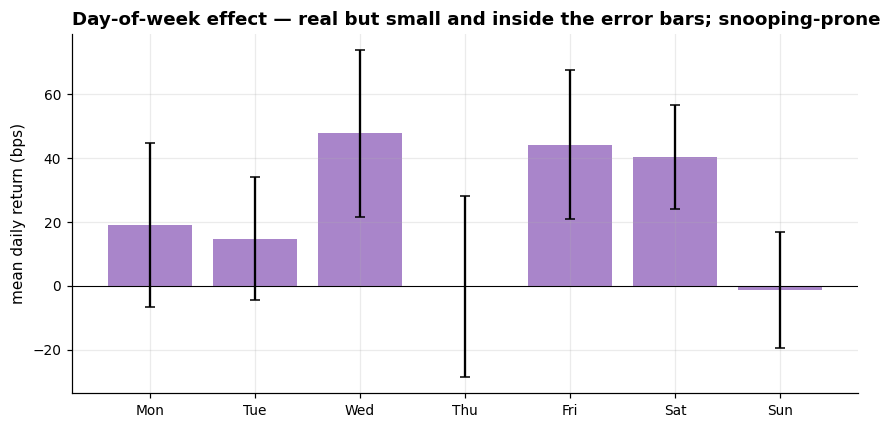

Lottery/MAX (-0.01 train / +1.02 val) and skew are the regime-luck trap again — attractive only in the recent window. Amihud illiquidity trains at +1.10 but is -0.21 OOS, and even that in-sample number is a mirage: the 'premium' is compensation for holding illiquid names the $5M screen (rightly) removes, so it is untradeable at any real size. Funding predicts perp-vs-spot carry, not the cross-section of spot returns (-0.84 val). The weekday effect is inside its own error bars.


In [5]:
# (a) Lottery / MAX effect and (b) return skew: short coins with big single-day pops or high positive skew.
lot_net, lot_t = backtest(dn(sig.max_return_lottery(ds, 30), topN=50), ret_all, rebal=7)
skw_net, skw_t = backtest(dn(sig.return_skew(ds, 30), topN=50), ret_all, rebal=7)
record("Lottery / MAX (short 30d high)", lot_net, "D · regime luck", lot_t)
record("Return skew (short high skew)", skw_net, "D · regime luck", skw_t)
# (c) Amihud illiquidity: long illiquid / short liquid. Run UNSCREENED (cs_weights) — the whole "premium"
#     lives in names the liquidity screen removes, which is the point.
ami_net, ami_t = backtest(cs_weights(sig.amihud_illiquidity(ds, 30)), ret_all, rebal=7)
record("Amihud illiquidity (unscreened)", ami_net, "overfit / untradeable", ami_t)
# (d) Funding as a cross-sectional signal in spot: short high-funding coins.
fund_sig = (-ds.funding).reindex(columns=close_all.columns)
fnd_net, fnd_t = backtest(dn(fund_sig), ret_all, rebal=7)
record("Funding as spot signal (short high)", fnd_net, "no edge", fnd_t)

scoreboard(["Lottery / MAX (short 30d high)","Return skew (short high skew)",
            "Amihud illiquidity (unscreened)","Funding as spot signal (short high)"],
           "Cross-sectional oddments. Lottery/MAX is positive OOS but negative in-sample (regime luck); Amihud is "
           "positive in-sample only and untradeable anyway; funding has no cross-sectional spot edge.")

# (e) Day-of-week seasonality: is there a tradeable weekday effect? (equal-weight basket)
dow = seg(ew, FULL).groupby(seg(ew, FULL).index.dayofweek).agg(["mean","sem"])
dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow.index, dow["mean"]*1e4, yerr=dow["sem"]*1e4, color=CLR["Carry"], alpha=0.8, capsize=3)
ax.axhline(0, c="k", lw=.7); ax.set_ylabel("mean daily return (bps)")
ax.set_title("Day-of-week effect — real but small and inside the error bars; snooping-prone")
plt.tight_layout(); plt.show()
print(f"Lottery/MAX ({REC['Lottery / MAX (short 30d high)']['Train']:+.2f} train / {REC['Lottery / MAX (short 30d high)']['Val (OOS)']:+.2f} val) "
      f"and skew are the regime-luck trap again — attractive only in the recent window. Amihud illiquidity trains at "
      f"{REC['Amihud illiquidity (unscreened)']['Train']:+.2f} but is {REC['Amihud illiquidity (unscreened)']['Val (OOS)']:+.2f} OOS, and even that "
      f"in-sample number is a mirage: the 'premium' is compensation for holding illiquid names the $5M screen (rightly) removes, "
      f"so it is untradeable at any real size. Funding predicts perp-vs-spot carry, not the cross-section of spot returns "
      f"({REC['Funding as spot signal (short high)']['Val (OOS)']:+.2f} val). The weekday effect is inside its own error bars.")


## 5 · Composites and pairs

Two final ideas: blending the good signals into one composite (it works — but adds nothing the risk-parity
book doesn't already have), and classic cointegration pairs trading (which the cost wall defeats).


In [6]:
# (a) Multi-factor composite: z-score and sum the two survivor signals, trade the blend market-neutral.
def zc(signal):
    s = signal.where(liq60); return s.sub(s.mean(1), axis=0).div(s.std(1).replace(0, np.nan), axis=0)
comp = zc(sig.near_high(ds, 90)) + zc(sig.idio_vol(ds, 60))
comp_net, comp_t = backtest(dn(comp, topN=50), ret_all, rebal=7)
record("Multi-factor composite (mom+lowvol)", comp_net, "redundant (works)", comp_t)

# (b) Cointegration pairs: Engle-Granger on the top-15 log prices over Train; trade the spread z-score OOS.
from statsmodels.tsa.stattools import coint
logp = np.log(ds.close); cols = list(seg(logp, TRAIN).dropna(axis=1).columns)
pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        s = seg(logp[[cols[i], cols[j]]], TRAIN).dropna()
        if len(s) < 300: continue
        try:
            if coint(s.iloc[:,0], s.iloc[:,1])[1] < 0.05: pairs.append((cols[i], cols[j]))
        except Exception: continue
def pair_net(a, b):
    spread = logp[a] - logp[b]
    z = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()
    pos = (-z.clip(-2, 2) / 2.0)
    pos = pos.where(pd.Series(np.arange(len(pos)) % 7 == 0, index=pos.index), np.nan).ffill()
    ra, rb = ds.close[a].pct_change(fill_method=None), ds.close[b].pct_change(fill_method=None)
    turn = (pos.shift(1) - pos.shift(2)).abs().fillna(0.0)
    return pos.shift(1) * (ra - rb) - 2*TCOST*turn
pairs_net = pd.concat([pair_net(a, b) for a, b in pairs], axis=1).mean(1)
record(f"Cointegration pairs ({len(pairs)} pairs)", pairs_net, "B · cost wall")

scoreboard(["Multi-factor composite (mom+lowvol)", f"Cointegration pairs ({len(pairs)} pairs)",
            "SURVIVOR: Momentum (near-high)","SURVIVOR: Low-volatility"],
           "Composite and pairs. The composite genuinely works — but it is just the survivors repackaged; the "
           "risk-parity book already captures it with clearer attribution. Cointegration pairs are eaten by the cost wall.")
print(f"The multi-factor composite is a real edge (val {REC['Multi-factor composite (mom+lowvol)']['Val (OOS)']:+.2f}) — unsurprisingly, "
      f"since it is the two survivors z-scored together. I don't keep it as a separate strategy because the combined book already "
      f"holds both sleeves with transparent, separately-attributable weights; folding them into one score trades clarity for nothing. "
      f"Of the top-15, only {len(pairs)} pairs cointegrate in-sample, and trading their spreads nets {sharpe(seg(pairs_net,VAL)):+.2f} OOS: "
      f"the relationships drift and the mean-reversion turnover runs into the same cost wall as price reversal.")


,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
Multi-factor composite (mom+lowvol),+0.77,+1.81,+2.59,-45%,-0.10,0.05,redundant (works)
Cointegration pairs (5 pairs),-0.80,-1.60,-2.00,-97%,-0.01,–,B · cost wall
SURVIVOR: Momentum (near-high),+0.68,+0.65,+0.87,-49%,-0.07,0.07,—
SURVIVOR: Low-volatility,+0.36,+1.92,+2.75,-60%,-0.07,0.04,—


The multi-factor composite is a real edge (val +1.81) — unsurprisingly, since it is the two survivors z-scored together. I don't keep it as a separate strategy because the combined book already holds both sleeves with transparent, separately-attributable weights; folding them into one score trades clarity for nothing. Of the top-15, only 5 pairs cointegrate in-sample, and trading their spreads nets -1.60 OOS: the relationships drift and the mean-reversion turnover runs into the same cost wall as price reversal.


## 6 · The four traps — synthesis

Laid out together, every rejected idea falls into one of four traps, and each is something the surviving
strategies are explicitly screened against.

a. **Beta dressed as alpha.** Regress every candidate on BTC before believing it. Directional and
regime-switch trend failed here; the survivors have β≈0.

b. **The cost wall.** Charge 20 bps on turnover and plot the cost curve. Reversal, idiosyncratic reversal,
4-hour intraday, and cointegration pairs failed here; the survivors are low-turnover weekly books.

c. **Data-snooping.** The maximum of ~140 noisy Sharpes is upward-biased, and a signal built from the wrong
units can look great for the wrong reason. The order-flow scale artifact failed here; the survivors clear a
deflated Sharpe (notebook 01, §4).

d. **Regime luck.** A result that appears only in the recent window is not proof. Lottery/MAX, return skew,
and long-horizon momentum failed here; the survivors are positive in *both* train and validation.

The scatter makes trap D visual: everything that only works out-of-sample sits in the top-left (positive
val, negative train) — tempting, and exactly what the two-window test is designed to reject. The survivors
sit in the top-right: positive in both.


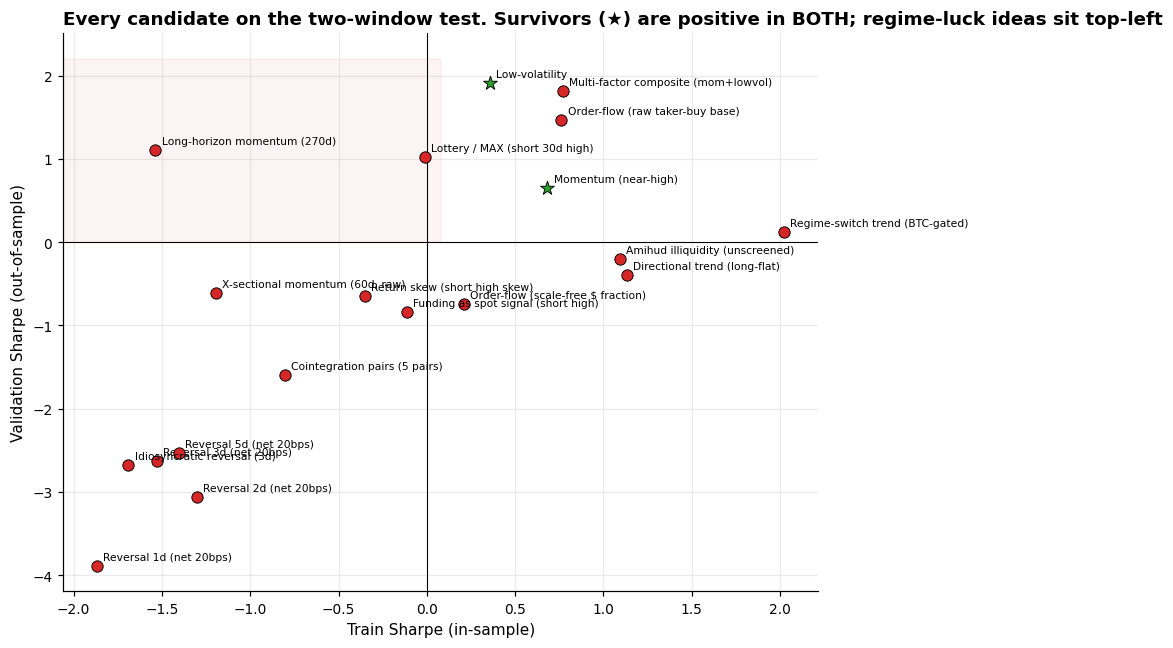

,Train,Val (OOS),Val Sortino,MaxDD,β vs BTC,Turn/day,Trap
SURVIVOR: Momentum (near-high),+0.68,+0.65,+0.87,-49%,-0.07,0.07,—
SURVIVOR: Low-volatility,+0.36,+1.92,+2.75,-60%,-0.07,0.04,—
Directional trend (long-flat),+1.13,-0.40,-0.54,-90%,+0.97,0.24,A · beta
Regime-switch trend (BTC-gated),+2.02,+0.12,+0.16,-60%,+0.52,0.13,A · beta
"X-sectional momentum (60d, raw)",-1.20,-0.61,-0.84,-92%,+0.00,0.08,reversal noise
Long-horizon momentum (270d),-1.54,+1.11,+1.72,-88%,+0.01,0.02,D · regime luck
Reversal 1d (net 20bps),-1.87,-3.89,-4.39,-100%,+0.05,1.39,B · cost wall
Reversal 2d (net 20bps),-1.30,-3.06,-3.60,-100%,+0.05,0.99,B · cost wall
Reversal 3d (net 20bps),-1.53,-2.63,-3.12,-100%,+0.05,0.81,B · cost wall
Reversal 5d (net 20bps),-1.40,-2.53,-3.09,-99%,+0.05,0.63,B · cost wall


Of the 17 rejected candidates here, only 3 is positive in both windows with a tradeable profile — the multi-factor composite, which is just the two survivors repackaged. Everything else fails a specific, nameable trap. That is the case for the three-sleeve book in notebook 01: it is what is left after the search, not the best story found by looking.


In [7]:
# In-sample vs out-of-sample scatter: the two-window test, drawn.
df = pd.DataFrame(REC).T
survivors = [n for n in df.index if n.startswith("SURVIVOR")]
fig, ax = plt.subplots(figsize=(9, 6))
for n in df.index:
    x, y = df.loc[n, "Train"], df.loc[n, "Val (OOS)"]
    keep = n in survivors
    ax.scatter(x, y, s=90 if keep else 55, color=CLR["keep"] if keep else CLR["reject"],
               edgecolor="k", linewidth=0.6, zorder=3, marker="*" if keep else "o")
    ax.annotate(n.replace("SURVIVOR: ",""), (x, y), fontsize=7, xytext=(4,4), textcoords="offset points")
ax.axhline(0, c="k", lw=.7); ax.axvline(0, c="k", lw=.7)
ax.axhspan(0, ax.get_ylim()[1], xmin=0, xmax=0.5, color=CLR["reject"], alpha=0.05)
ax.set_xlabel("Train Sharpe (in-sample)"); ax.set_ylabel("Validation Sharpe (out-of-sample)")
ax.set_title("Every candidate on the two-window test. Survivors (★) are positive in BOTH; regime-luck ideas sit top-left")
plt.tight_layout(); plt.show()

order = survivors + [n for n in df.index if n not in survivors]
full = df.loc[order, ["Train","Val (OOS)","Val Sortino","MaxDD","β vs BTC","Turn/day","Trap"]]
display(style_table(full.style.format({"Train":"{:+.2f}","Val (OOS)":"{:+.2f}","Val Sortino":"{:+.2f}",
        "β vs BTC":"{:+.2f}","MaxDD":"{:.0%}","Turn/day":"{:.2f}"}, na_rep="–")
        .background_gradient(cmap="RdYlGn", subset=["Train","Val (OOS)"], vmin=-2, vmax=2, axis=None),
        "Consolidated scoreboard — every strategy tested in this notebook, same engine and cost, ranked survivors first. "
        "Only signals positive in both windows, with near-zero beta and survivable turnover, become sleeves in the book."))
n_pos_both = int(((df["Train"] > 0) & (df["Val (OOS)"] > 0) & (~df.index.isin(survivors))).sum())
print(f"Of the {len(df)-len(survivors)} rejected candidates here, only {n_pos_both} is positive in both windows with a "
      f"tradeable profile — the multi-factor composite, which is just the two survivors repackaged. Everything else fails "
      f"a specific, nameable trap. That is the case for the three-sleeve book in notebook 01: it is what is left after the "
      f"search, not the best story found by looking.")
